In [131]:
from tools import get_metadata, get_volume, plot_pod_energy, plot_pod_modes #, plot_slices to be made
import numpy as np
import matplotlib.pyplot as plt

In [93]:
# --- 1. METADATA FROM FILE ---
metadata = get_metadata("golf_slice_c1.h5", 'c1', u=9, z=2) # Case c1 has u=9.0 and z=2.0

# --- 2. DATA COLLECTION (The "Snapshots") ---
print("Collecting snapshots from HDF5...")
snapshots = []
Nt = 600 # 10 minutes of data

for t in range(Nt):
    # This now returns a (6, 26, 51) array
    vol = get_volume(metadata, 'u', nt=t)
    snapshots.append(vol)

# Convert to 4D array: (Time, Z, Y, X)
u_total = np.array(snapshots)
Nt, Nz, Ny, Nx = u_total.shape

# --- 3. MEAN SUBTRACTION (Reynolds Decomposition) ---
print("Calculating mean and fluctuations...")
u_mean = np.mean(u_total, axis=0) # Shape: (6, 26, 51)
u_prime = u_total - u_mean

# --- 4. SNAPSHOT MATRIX CONSTRUCTION ---
# Flatten spatial dimensions into a single vector per timestep
# Shape: (Nt, Nz*Ny*Nx) -> Transpose to (SpatialPoints, Time)
X = u_prime.reshape(Nt, -1).T
print(f"Snapshot Matrix X ready. Shape: {X.shape}")

# --- 5. ECONOMY SVD (POD Calculation) ---
print("Performing SVD...")
U_modes, Sigma, Vt = np.linalg.svd(X, full_matrices=False)

User defined scaling
2
Calculating mean and fluctuations...
Snapshot Matrix X ready. Shape: (7956, 600)
Performing SVD...


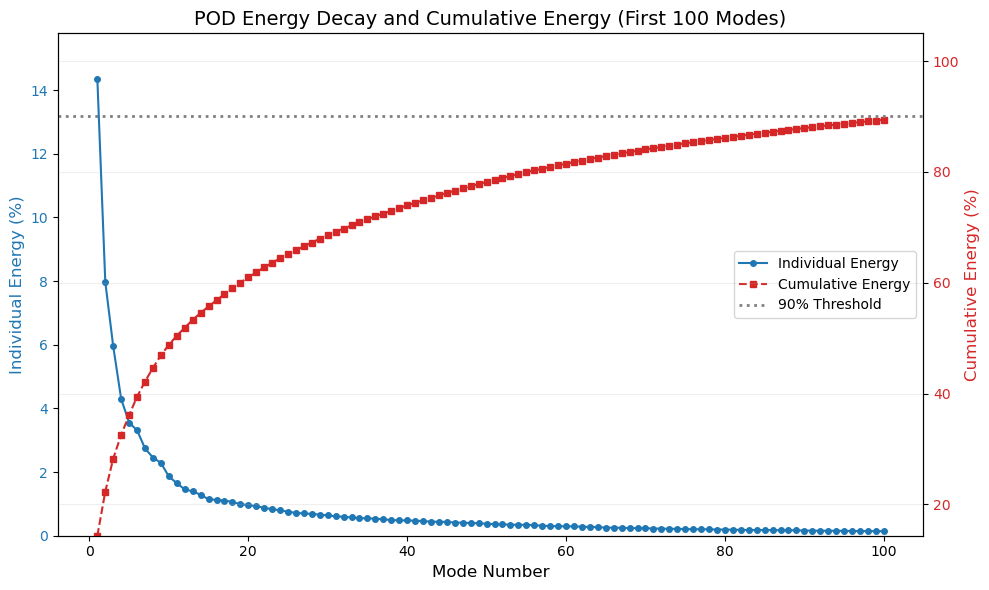

----------------------------------------
Number of modes to reach 90% energy: 105
Energy in the first 20 modes: 60.96%
----------------------------------------


In [94]:
# --- 6. ENERGY CALCULATION ---
energy = Sigma**2
total_energy = np.sum(energy)
relative_energy = (energy / total_energy) * 100
cumulative_energy = np.cumsum(relative_energy)

plot_pod_energy(relative_energy, cumulative_energy)

# 90% Milestone Print
n_90 = np.argmax(cumulative_energy >= 90) + 1
print("-" * 40)
print(f"Number of modes to reach 90% energy: {n_90}")
print(f"Energy in the first 20 modes: {cumulative_energy[19]:.2f}%")
print("-" * 40)

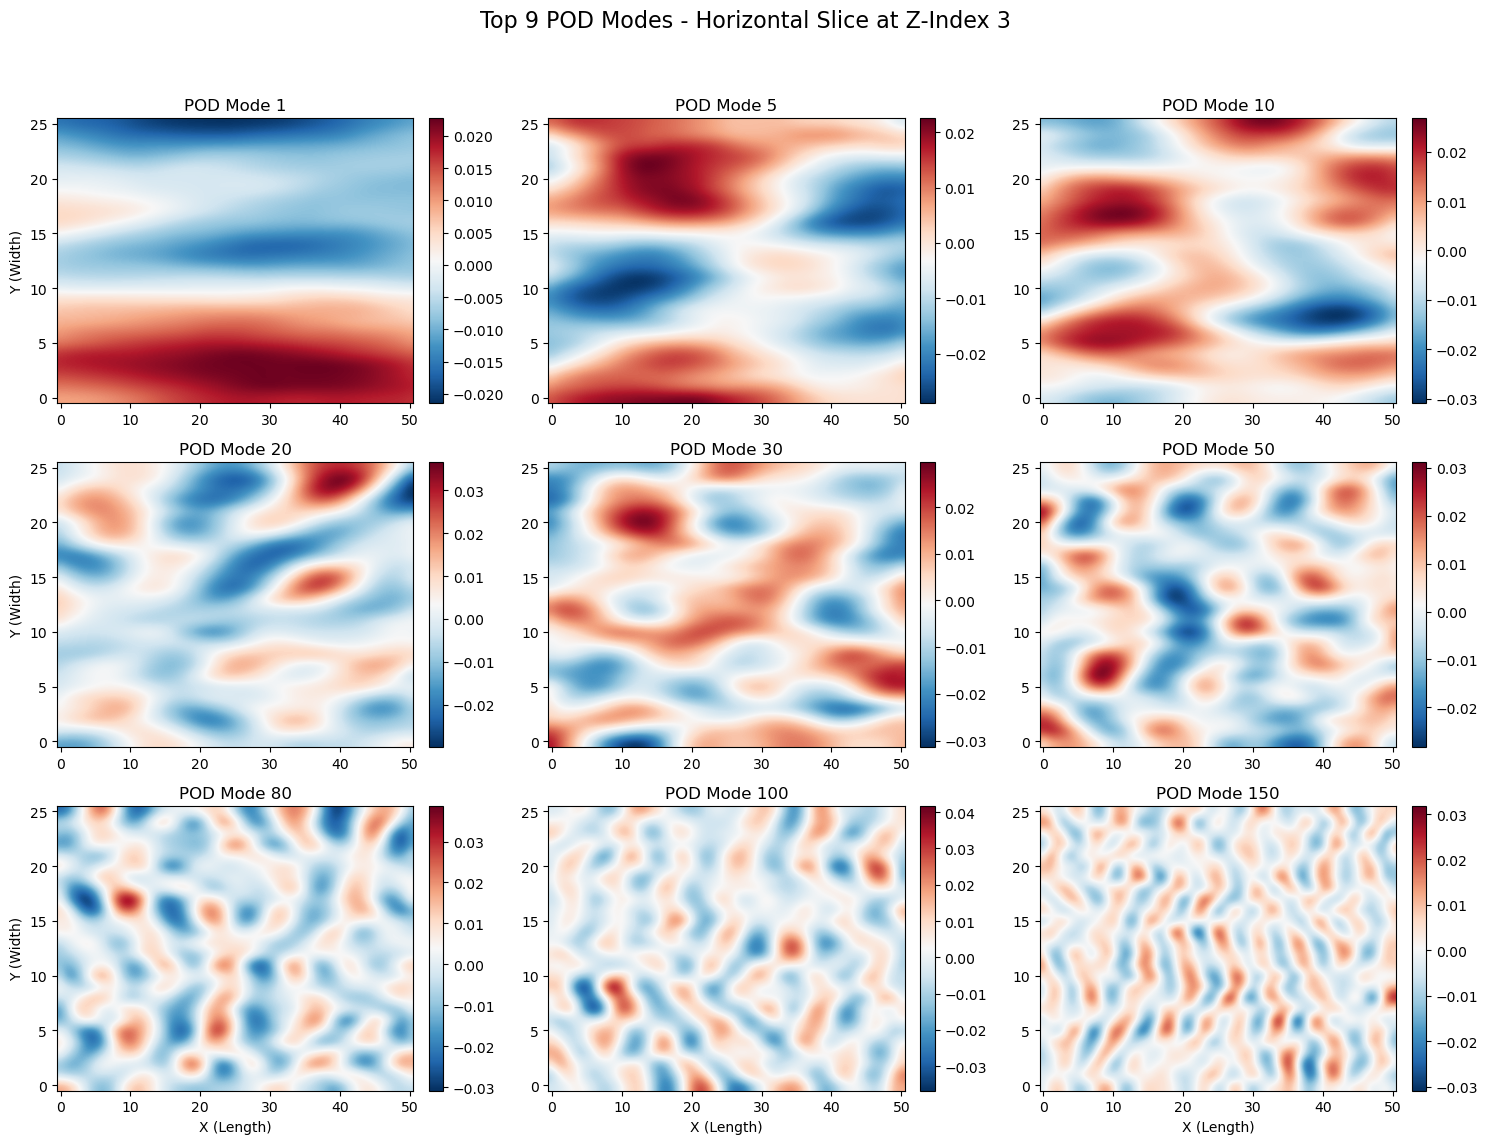

In [99]:
# Based on your previous output: Nz=6, Ny=26, Nx=51
plot_pod_modes(U_modes, 6, 26, 51)

In [100]:
# --- 7. PS-ROM RECONSTRUCTION (using n modes) ---

def create_rom(U_modes, Sigma, Vt, n_modes):
    # Reconstruct fluctuations: (SpatialPoints x n_modes) @ (n_modes x Time)
    X_rom_prime = U_modes[:, :n_modes] @ (np.diag(Sigma[:n_modes]) @ Vt[:n_modes, :])

    # Reshape back to 4D: (SpatialPoints, Time) -> (Time, Z, Y, X)
    u_rom_prime = X_rom_prime.T.reshape(Nt, Nz, Ny, Nx)

    # Add the mean back to get full velocity
    u_rom = u_rom_prime + u_mean

    return u_rom

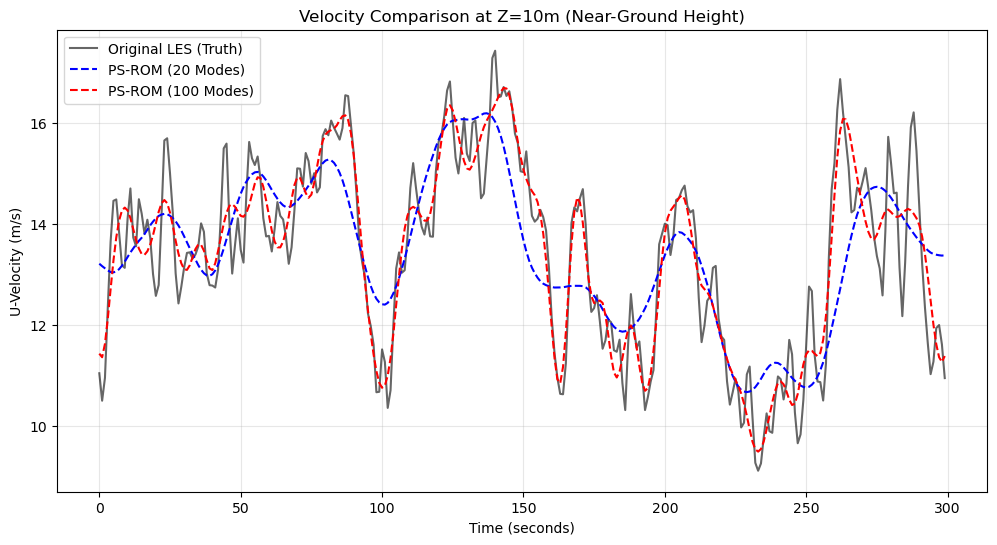

In [101]:
# --- 8. COMPARISON PLOT (Time Series) ---
# Choose a probe point: near-ground-height (index 1), Center of field
z_idx, y_idx, x_idx = 1, Ny//2, Nx//2

end_t = 300

plt.figure(figsize=(12, 6))

# Plot Original LES (The "Truth")
plt.plot(u_total[:end_t, z_idx, y_idx, x_idx], 
         label='Original LES (Truth)', color='black', alpha=0.6)

# Plot PS-ROM Reconstruction
n_modes = 20
u_rom = create_rom(U_modes, Sigma, Vt, n_modes)
plt.plot(u_rom[:end_t, z_idx, y_idx, x_idx], 
         label=f'PS-ROM ({n_modes} Modes)', color='blue', linestyle='--')

n_modes = 100
u_rom = create_rom(U_modes, Sigma, Vt, n_modes)
plt.plot(u_rom[:end_t, z_idx, y_idx, x_idx], 
         label=f'PS-ROM ({n_modes} Modes)', color='red', linestyle='--')

plt.title(f"Velocity Comparison at Z={z_idx*10}m (Near-Ground Height)")
plt.xlabel("Time (seconds)")
plt.ylabel("U-Velocity (m/s)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

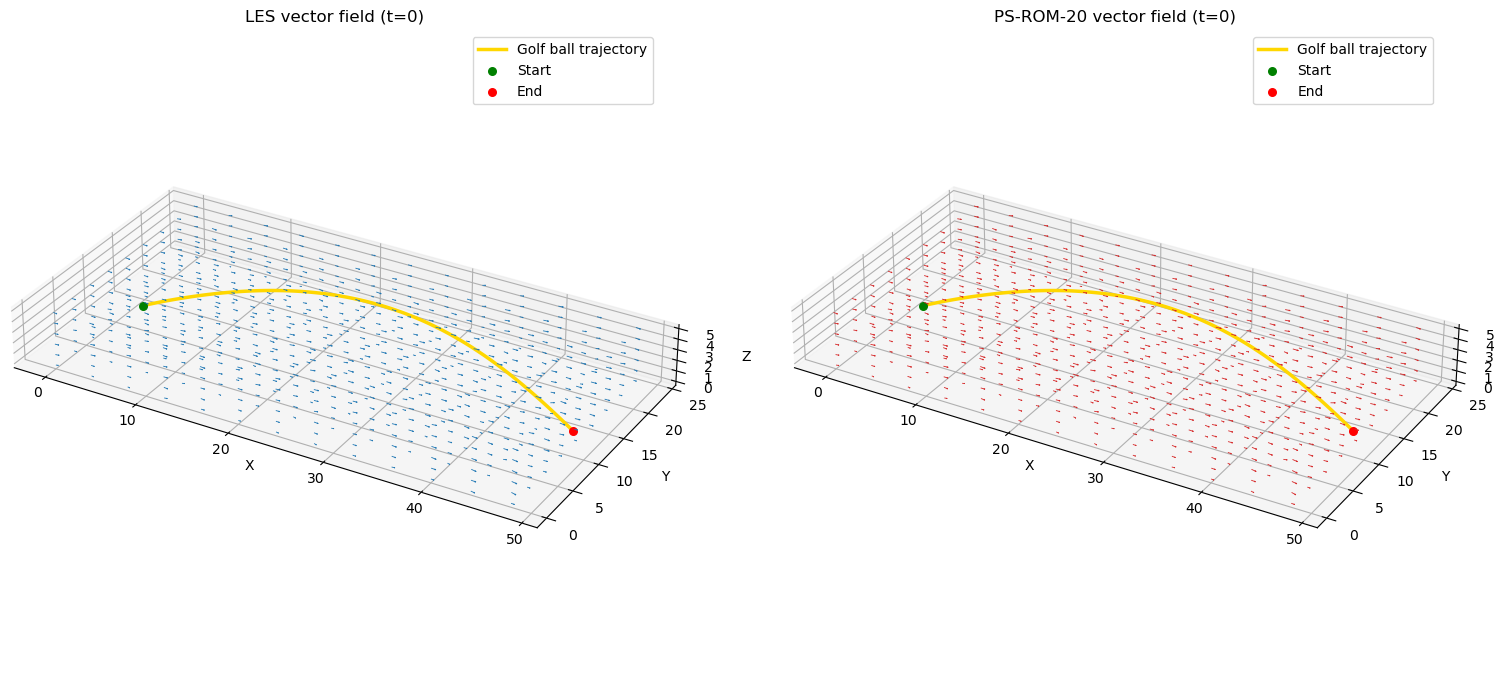

In [ ]:
# t = 0 fields
u_les = u_total[0]
u_rom20 = create_rom(U_modes, Sigma, Vt, 20)[0]

# Get LES v and w at t=0 (for full vector plotting)
v_les = get_volume(metadata, "v", nt=0)
w_les = get_volume(metadata, "w", nt=0)

def to_zyx(arr, Nz, Ny, Nx):
    if arr.shape == (Nz, Ny, Nx):
        return arr
    if arr.shape == (Ny, Nx, Nz):
        return np.transpose(arr, (2, 0, 1))
    raise ValueError(f"Unexpected shape {arr.shape}, expected {(Nz, Ny, Nx)} or {(Ny, Nx, Nz)}")

v_les = to_zyx(v_les, Nz, Ny, Nx)
w_les = to_zyx(w_les, Nz, Ny, Nx)

# For PS-ROM-20, only u is reconstructed in this notebook setup
v_rom20 = v_les
w_rom20 = w_les

# Grid (index space) + downsampling
Z, Y, Xg = np.meshgrid(np.arange(Nz), np.arange(Ny), np.arange(Nx), indexing="ij")
sz, sy, sx = 1, 3, 4
sl = (slice(None, None, sz), slice(None, None, sy), slice(None, None, sx))

# Simple golf-ball trajectory in index space
n_traj = 120
s = np.linspace(0, 1, n_traj)
x_traj = np.linspace(2, Nx - 3, n_traj)
y_traj = Ny * 0.45 + 0.18 * Ny * np.sin(np.pi * s)    # slight side curve
z_traj = 1.0 + (Nz - 1.2 - 1.0) * 4 * s * (1 - s)     # parabola
z_traj = np.clip(z_traj, 0, Nz - 1)

fig = plt.figure(figsize=(16, 7))

ax1 = fig.add_subplot(1, 2, 1, projection="3d")
ax1.quiver(
    Xg[sl], Y[sl], Z[sl],
    u_les[sl], v_les[sl], w_les[sl],
    length=0.03, normalize=False, color="tab:blue", linewidth=0.6
)
ax1.plot(x_traj, y_traj, z_traj, color="gold", lw=2.5, label="Golf ball trajectory")
ax1.scatter(x_traj[0], y_traj[0], z_traj[0], color="green", s=30, label="Start")
ax1.scatter(x_traj[-1], y_traj[-1], z_traj[-1], color="red", s=30, label="End")
ax1.set_title("LES vector field (t=0)")
ax1.set_xlabel("X")
ax1.set_ylabel("Y")
ax1.set_zlabel("Z")
ax1.set_box_aspect((Nx, Ny, Nz))
ax1.legend(loc="upper right")

ax2 = fig.add_subplot(1, 2, 2, projection="3d")
ax2.quiver(
    Xg[sl], Y[sl], Z[sl],
    u_rom20[sl], v_rom20[sl], w_rom20[sl],
    length=0.03, normalize=False, color="tab:red", linewidth=0.6
)
ax2.plot(x_traj, y_traj, z_traj, color="gold", lw=2.5, label="Golf ball trajectory")
ax2.scatter(x_traj[0], y_traj[0], z_traj[0], color="green", s=30, label="Start")
ax2.scatter(x_traj[-1], y_traj[-1], z_traj[-1], color="red", s=30, label="End")
ax2.set_title("PS-ROM-20 vector field (t=0)")
ax2.set_xlabel("X")
ax2.set_ylabel("Y")
ax2.set_zlabel("Z")
ax2.set_box_aspect((Nx, Ny, Nz))
ax2.legend(loc="upper right")

plt.tight_layout()
plt.show()

In [110]:
u_total[:1, z_idx, y_idx, x_idx]

array([11.04655], dtype=float32)

In [123]:
metadata['x'].shape[0]*20, metadata['y'].shape[0]*20

(1020, 520)